# UK E-Commerce Data Analysis
### Internship Project | Task 1: Exploratory Data Analysis (EDA)

---

## 1. Project Context
This analysis is part of a Data Analyst internship project. The goal is to extract actionable business insights from real-world transactional data, demonstrate data cleaning proficiency, and answer key commercial questions.

**Dataset:** *Online Retail* (UCI Machine Learning Repository)  
**Source:** A UK-based, non-store online retailer selling unique all-occasion gifts (2010–2011).  
**Note:** Many customers are wholesalers—this B2B nuance influences outlier treatment.

---

## 2. Dataset Snapshot
- **Records:** ~541,000+ transactions  
- **Timeframe:** 01/12/2010 – 09/12/2011  
- **Key Fields:** InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country  

---

## 3. Notebook Objective
- **Clean** – Handle missing IDs, negatives, and inconsistencies.
- **Explore** – Uncover sales patterns, product performance, and customer behavior.
- **Answer** – 8 business questions (revenue, top products, trends, outliers, etc.).

---

## 4. Analysis Roadmap
1. Data Preparation & Cleaning  
2. Exploratory Data Analysis (Visuals + Stats)  
3. Business Questions – Answers & Insights  
4. Summary & Recommendations

---



In [1]:
# import librarie
import pandas as pd #pandas is a powerful data manipulation library
import numpy as np #numpy is a fundamental package for scientific computing
import matplotlib.pyplot as plt #matplotlib.pyplot is a plotting library
import seaborn as sns #seaborn is a statistical data visualization library
import warnings #warnings is a built-in library for handling warnings
warnings.filterwarnings("ignore")   # Ignore warnings

# set visualization style
sns.set(style="whitegrid") # Set the style of seaborn plots to whitegrid
plt.rcParams['figure.figsize'] = (10, 6) # Set the default figure size for plots


In [2]:
# load the dataset
df = pd.read_csv('data.csv', encoding='latin-1') 
df.head() # Display the first 5 rows of the dataframe

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape # Display the shape of the dataframe (number of rows and columns)

(541909, 8)

## Initial Inspection

In [4]:
df.info() # Display information about the dataframe, including column names, data types, and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe() # Display summary statistics for numerical columns in the dataframe

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
df.isnull().sum() # Check for missing values in the dataframe and display the count of missing values for each column   

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
# Check for duplicate rows in the dataframe
duplicate_rows = df[df.duplicated()] # Identify duplicate rows in the dataframe
duplicate_rows.shape[0] # Display the number of duplicate rows

5268

In [8]:
print("Number of duplicate rows: ", duplicate_rows.shape[0]) # Print the number of duplicate rows

Number of duplicate rows:  5268


In [9]:
print(duplicate_rows) # Display the duplicate rows in the dataframe

       InvoiceNo StockCode                        Description  Quantity  \
517       536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
527       536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
537       536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
539       536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
555       536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   
...          ...       ...                                ...       ...   
541675    581538     22068        BLACK PIRATE TREASURE CHEST         1   
541689    581538     23318     BOX OF 6 MINI VINTAGE CRACKERS         1   
541692    581538     22992             REVOLVER WOODEN RULER          1   
541699    581538     22694                       WICKER STAR          1   
541701    581538     23343       JUMBO BAG VINTAGE CHRISTMAS          1   

            InvoiceDate  UnitPrice  CustomerID         Country  
517     12/1/2010 11:45       1.25

In [10]:
duplicate_rows.isnull().sum() # Check for missing values in the duplicate rows and display the count of missing values for each column

InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID     43
Country         0
dtype: int64

In [11]:
# Check unique values in each column
for column in df.columns:
    unique_values = df[column].nunique() # Get the number of unique values in the column
    print(f"Column '{column}' has {unique_values} unique values.") # Print the number of unique values for each column  
    

Column 'InvoiceNo' has 25900 unique values.
Column 'StockCode' has 4070 unique values.
Column 'Description' has 4223 unique values.
Column 'Quantity' has 722 unique values.
Column 'InvoiceDate' has 23260 unique values.
Column 'UnitPrice' has 1630 unique values.
Column 'CustomerID' has 4372 unique values.
Column 'Country' has 38 unique values.


## The Deep Clean

In [12]:
# 1. Drop duplicate rows
df.drop_duplicates(inplace=True) # Drop duplicate rows from the dataframe and modify it in place
print("Number of duplicate rows after dropping duplicates: ", df.duplicated().sum()) # Print the number of duplicate rows after dropping duplicates

Number of duplicate rows after dropping duplicates:  0


In [13]:
df.shape # Display the shape of the dataframe (number of rows and columns)

(536641, 8)

In [14]:
df.isnull().sum() # Check for missing values in the dataframe and display the count of missing values for each column

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [15]:
# Handle negatives and returns in the 'Quantity' column
returns = df[df['Quantity'] < 0] # Identify rows with negative quantities (returns)
print("Number of returns (negative quantities): ", returns.shape[0]) # Print the number of returns

Number of returns (negative quantities):  10587


In [16]:
df[df['UnitPrice'] < 0] # Display rows with negative unit prices
print("Number of rows with negative unit prices: ", df[df['UnitPrice'] < 0].shape[0]) # Print the number of rows with negative unit prices

Number of rows with negative unit prices:  2


In [17]:
# Keep only positive quantities in the 'Quantity' column
df_clean = df[(df['Quantity'] >= 0) & (df['UnitPrice'] >= 0)] # Filter the dataframe to keep only rows with non-negative quantities and unit prices 
print(f"Removed {len(df) - len(df_clean)} rows with negative quantities or unit prices.") # Print the number of rows removed due to negative quantities or unit prices  

Removed 10589 rows with negative quantities or unit prices.


In [18]:
# Handle missing customer IDs
# We can keep these rows for revenue calculations, but we will exclude them from customer analysis. 
df_clean['Has_CustomerID'] = df_clean['CustomerID'].notnull() # Create a new column 'Has_CustomerID' to indicate whether the 'CustomerID' is present or not 
print(f"Missing CustomerIDs: {df_clean['CustomerID'].isna().sum()}") # Print the number of rows with missing CustomerIDs   
print(f"Percentage of Missing CustomerIDs: {df_clean['CustomerID'].isna().mean() * 100:.2f}%") # Print the percentage of rows with missing CustomerIDs  

Missing CustomerIDs: 133320
Percentage of Missing CustomerIDs: 25.34%


In [19]:
df_clean.dtypes # Display the data types of each column in the dataframe

InvoiceNo          object
StockCode          object
Description        object
Quantity            int64
InvoiceDate        object
UnitPrice         float64
CustomerID        float64
Country            object
Has_CustomerID       bool
dtype: object

In [20]:
df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('5')]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Has_CustomerID
299982,A563185,B,Adjust bad debt,1,8/12/2011 14:50,11062.06,NaN,United Kingdom,False


In [21]:
# 1. Remove the alphabetical prefixes (e.g., 'A563185' becomes '563185')
df_clean['InvoiceNo'] = df_clean['InvoiceNo'].astype(str).str.replace(r'[a-zA-Z]', '', regex=True)

# 2. Convert to numeric (errors='coerce' turns any remaining unconvertible values into NaN)
df_clean['InvoiceNo'] = pd.to_numeric(df_clean['InvoiceNo'], errors='coerce')

In [22]:
df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('5')]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Has_CustomerID


In [24]:
df_clean.loc[299982]

InvoiceNo                  563185
StockCode                       B
Description       Adjust bad debt
Quantity                        1
InvoiceDate       8/12/2011 14:50
UnitPrice                11062.06
CustomerID                    NaN
Country            United Kingdom
Has_CustomerID              False
Name: 299982, dtype: object

In [25]:
df_clean['InvoiceDate'].unique() # Display unique values in the 'InvoiceDate' column]

array(['12/1/2010 8:26', '12/1/2010 8:28', '12/1/2010 8:34', ...,
       '12/9/2011 12:31', '12/9/2011 12:49', '12/9/2011 12:50'],
      dtype=object)

In [26]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='%m/%d/%Y %H:%M') # Convert the 'InvoiceDate' column to datetime format

In [27]:
df_clean.dtypes # Display the data types of each column in the dataframe after conversion

InvoiceNo                  int64
StockCode                 object
Description               object
Quantity                   int64
InvoiceDate       datetime64[ns]
UnitPrice                float64
CustomerID               float64
Country                   object
Has_CustomerID              bool
dtype: object

In [28]:
df_clean.isnull().sum() # Check for missing values in the cleaned dataframe and display the count of missing values for each column

InvoiceNo              0
StockCode              0
Description          592
Quantity               0
InvoiceDate            0
UnitPrice              0
CustomerID        133320
Country                0
Has_CustomerID         0
dtype: int64

In [29]:
df_clean[df_clean.isnull().any(axis=1)] # Display rows with missing values in the cleaned dataframe

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Has_CustomerID
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,False
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,False
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,False
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,False
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom,False
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom,False
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom,False
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom,False


## Feature engineering

In [30]:
# Creating revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice'] # Create a new column 'Revenue' by multiplying 'Quantity' and 'UnitPrice' to calculate the revenue for each transaction

In [31]:
# Extracting date features from the 'InvoiceDate' column
df_clean['Year'] = df_clean['InvoiceDate'].dt.year # Extract the year from the 'InvoiceDate' column and create a new column 'Year'
df_clean['Month'] = df_clean['InvoiceDate'].dt.month # Extract the month from the 'InvoiceDate' column and create a new column 'Month'        
df_clean['Day'] = df_clean['InvoiceDate'].dt.day # Extract the day from the 'InvoiceDate' column and create a new column 'Day'    
df_clean['Weekday'] = df_clean['InvoiceDate'].dt.weekday # Extract the weekday from the 'InvoiceDate' column and create a new column 'Weekday'
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour # Extract the hour from the 'InvoiceDate' column and create a new column 'Hour'  
df_clean.head() # Display the first 5 rows of the cleaned dataframe with the new date features

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Has_CustomerID,Revenue,Year,Month,Day,Weekday,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,True,15.30,2010,12,1,2,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,2010,12,1,2,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,True,22.00,2010,12,1,2,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,2010,12,1,2,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,2010,12,1,2,8


## Exploratory Data Analysis (Visuals   )

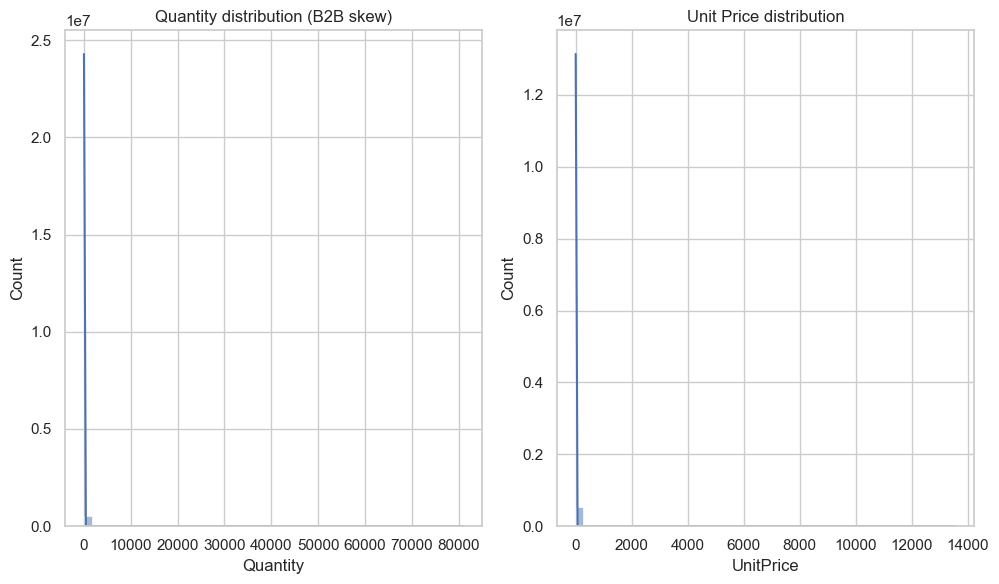

In [32]:
# Focus 1: Distribution of Revenue(Quantity * UnitPrice)
fig, ax = plt.subplots(1, 2, figsize=(10, 6)) # Create a new figure and axis for the plot
sns.histplot(df_clean['Quantity'], bins=50, kde=True, ax=ax[0]).set_title('Quantity distribution (B2B skew)') # Plot a histogram of the 'Quantity' column with 50 bins and a kernel density estimate (KDE) overlay
sns.histplot(df_clean['UnitPrice'], bins=50, kde=True, ax=ax[1]).set_title('Unit Price distribution') # Plot a histogram of the 'UnitPrice' column with 50 bins and a kernel density estimate (KDE) overlay 
plt.tight_layout() # Adjust the layout of the plot to prevent overlap
plt.show() # Display the plot

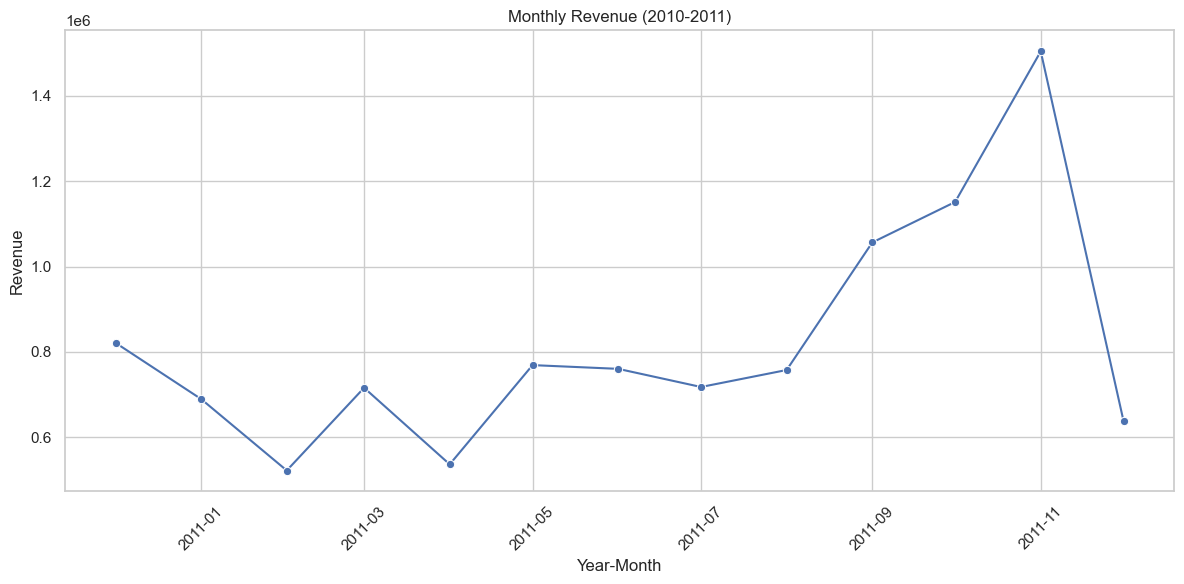

In [33]:
# Focus 2: Frequency of transactions over time(Monthly)
monthly_sales = df_clean.groupby(['Year', 'Month'])['Revenue'].sum().reset_index() # Group the cleaned dataframe by 'Year' and 'Month', sum the 'Revenue' for each group, and reset the index
monthly_sales['YearMonth'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(DAY=1)) # Create a new column 'YearMonth' by combining 'Year' and 'Month' and setting the day to 1
plt.figure(figsize=(12, 6)) # Create a new figure with specified size   
monthly_sales_plot = sns.lineplot(data=monthly_sales, x='YearMonth', y='Revenue', marker='o') # Plot a line graph of monthly revenue over time
monthly_sales_plot.set_title('Monthly Revenue (2010-2011)') # Set the title of the plot
plt.xlabel('Year-Month') # Set the x-axis label
plt.ylabel('Revenue') # Set the y-axis label
plt.xticks(rotation=45) # Rotate the x-axis labels by 45 degrees
plt.tight_layout() # Adjust the layout of the plot to prevent overlap
plt.show() # Display the plot

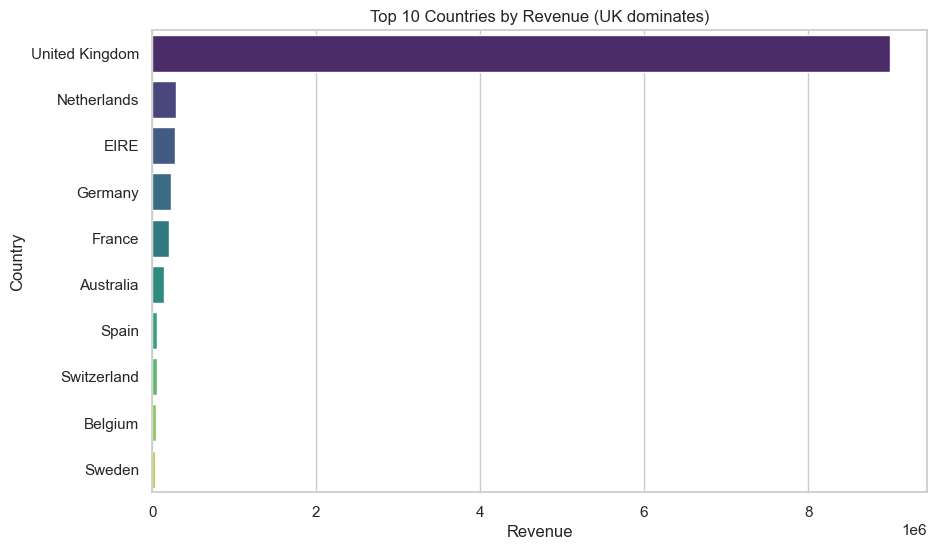

In [34]:
# Focus 3: Top Countries to see international sales
country_rev = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10) # Group the cleaned dataframe by 'Country', sum the 'Revenue' for each country, and sort in descending order to pick the top 10 countries by revenue
sns.barplot(x=country_rev.values, y=country_rev.index, palette='viridis') # Plot a horizontal bar chart of the top countries by revenue    
plt.title('Top 10 Countries by Revenue (UK dominates)') # Set the title of the plot
plt.xlabel('Revenue') # Set the x-axis label
plt.ylabel('Country') # Set the y-axis label
plt.show()

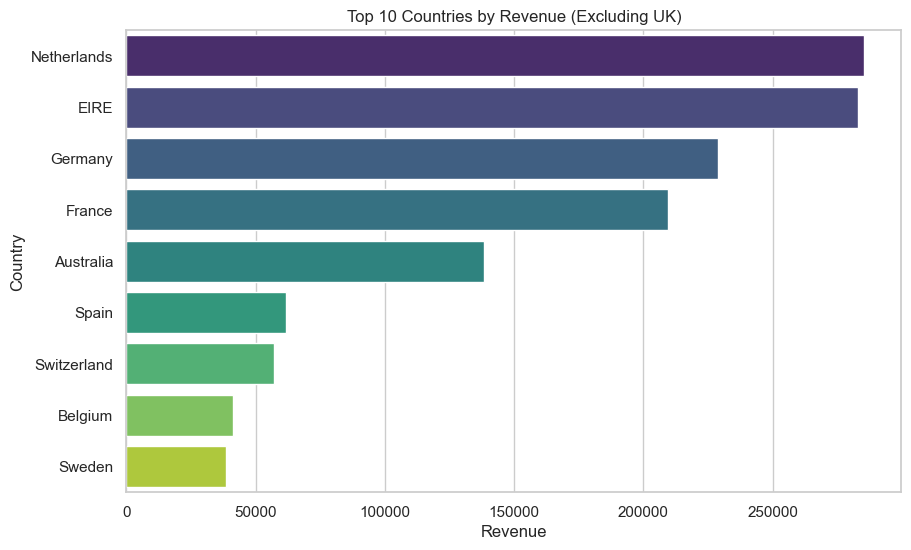

In [35]:
# Focus 3: Top Countries (Excluding UK to see international sales)
country_total = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10) # Group the cleaned dataframe by 'Country', sum the 'Revenue' for each country, and sort in descending order to pick the top 10 countries by revenue
country_without_uk = country_total[country_total.index != 'United Kingdom'] # Exclude the United Kingdom from the country revenue dataframe
sns.barplot(x=country_without_uk.values, y=country_without_uk.index, palette='viridis') # Plot a horizontal bar chart of the top countries by revenue    
plt.title('Top 10 Countries by Revenue (Excluding UK)') # Set the title of the plot
plt.xlabel('Revenue') # Set the x-axis label
plt.ylabel('Country') # Set the y-axis label
plt.show()

In [36]:
df['Country'].unique() # Display the unique countries in the cleaned dataframe

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

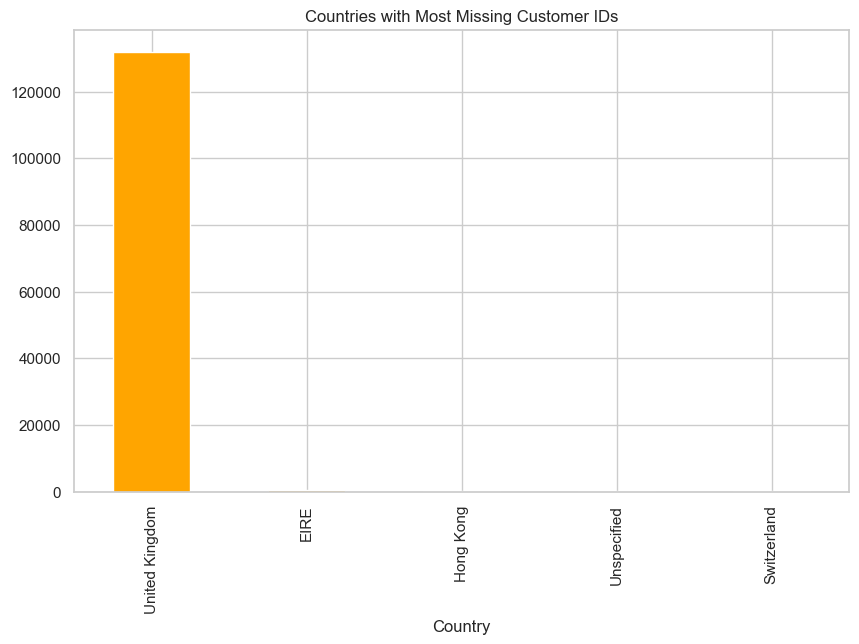

In [37]:
# Focus 4: Data Quality Visual (missing Customer IDs by Country)
missing_customer_ids = df_clean[df_clean['CustomerID'].isna()].groupby('Country').size().sort_values(ascending=False).head(5) # Filter the cleaned dataframe to get rows with missing CustomerIDs
missing_customer_ids.plot(kind='bar', color='orange') # Plot a bar chart of the number of missing CustomerIDs by country   
plt.title('Countries with Most Missing Customer IDs') # Set the title of the plot
plt.show() # Display the plot

In [38]:
df_clean['Description'].nunique() # Display the number of unique product descriptions in the cleaned dataframe

4077

## Q1: Total Revenue?

In [39]:
total_rev = df_clean['Revenue'].sum() # Calculate the total revenue by summing the 'Revenue' column in the cleaned dataframe
print(f"Total Revenue: £{total_rev}") # Print the total revenue

Total Revenue: £10642110.804000003


## Q2 & Q3: Top products by revenue and Quantity?

In [40]:
# Revenue
top_rev = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(5) # Group the cleaned dataframe by 'Description', sum the 'Revenue' for each description, and sort in descending order to pick the top 10 descriptions by revenue
print("🏆 Top Products by Revenue:\n", top_rev) 

# Quantity
top_quantity = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5) # Group the cleaned dataframe by 'Description', sum the 'Quantity' for each description, and sort in descending order to pick the top 10 descriptions by quantity
print("\n🏆 Top Products by Quantity:\n", top_quantity) # Print the top products by quantity

🏆 Top Products by Revenue:
 Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
Name: Revenue, dtype: float64

🏆 Top Products by Quantity:
 Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48375
WHITE HANGING HEART T-LIGHT HOLDER    37876
Name: Quantity, dtype: int64


## Q4: Low sales / Rare products?


In [41]:
# products that appear less than 5 times in the dataset
rare_products = df_clean['Description'].value_counts()[df_clean['Description'].value_counts()< 5] # Identify products that appear less than 5 times in the dataset    
print(f"🔍 Products that appear less than 5 times in the dataset:\n{rare_products}") # Print the products that appear less than 5 times in the dataset

🔍 Products that appear less than 5 times in the dataset:
Description
YELLOW/PINK CERAMIC CANDLE HOLDER     4
PINK BUNNY EASTER EGG BASKET          4
SET 10 CARDS DAVID'S MADONNA 17074    4
BLUE TILED TRAY                       4
ROBIN CHRISTMAS CARD                  4
                                     ..
BLOSSOM IMAGES SCRAP BOOK SET         1
LIGHT DECORATION BATTERY OPERATED     1
PAPER CRAFT , LITTLE BIRDIE           1
RUBY GLASS CLUSTER NECKLACE           1
ROCOCO WALL MIROR                     1
Name: count, Length: 537, dtype: int64


## Q5: Top Customers?

In [42]:
# Filter out missing Customer IDs before ranking
top_customers = df_clean[df_clean['CustomerID'].notnull()].groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(5) # Filter the cleaned dataframe to exclude rows with missing CustomerIDs, group by 'CustomerID', sum the 'Revenue' for each customer, and sort in descending order to pick the top 5 customers by revenue
print("\n👑 Top 5 Customers by Revenue:\n", top_customers) 


👑 Top 5 Customers by Revenue:
 CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
Name: Revenue, dtype: float64


In [43]:
# Filter out missing Customer IDs before ranking
top_customers = df_clean[df_clean['CustomerID'].notnull()] \
    .groupby('CustomerID')['Revenue'].sum() \
    .sort_values(ascending=False).head(5)

# Total revenue (across all customers with valid IDs)
total_revenue = df_clean[df_clean['CustomerID'].notnull()]['Revenue'].sum()

# Percentage contribution of each top customer
top_customer_pct = (top_customers / total_revenue) * 100

# Look at the result
print("\n👑 Top 5 Customers by Revenue:\n", top_customers)
print("\n📊 Percentage contribution:\n", top_customer_pct.round(2))


👑 Top 5 Customers by Revenue:
 CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
Name: Revenue, dtype: float64

📊 Percentage contribution:
 CustomerID
14646.0    3.15
18102.0    2.92
17450.0    2.19
16446.0    1.90
14911.0    1.62
Name: Revenue, dtype: float64


## Q6: Sales Trends (Daily/Monthly)?

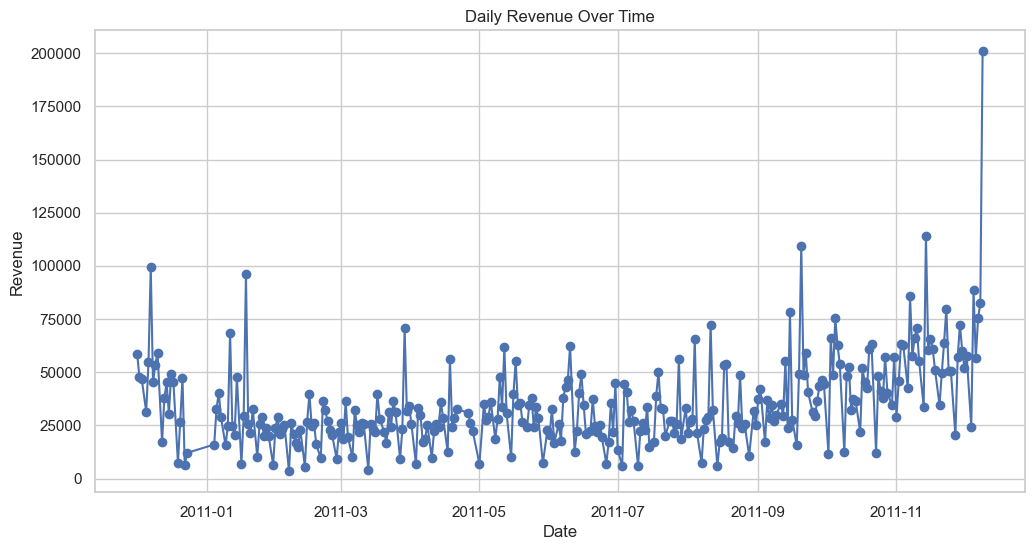

In [44]:
daily = df_clean.groupby(df_clean['InvoiceDate'].dt.date)['Revenue'].sum() # Group the cleaned dataframe by date (extracted from 'InvoiceDate') and sum the 'Revenue' for each day
daily.plot(figsize=(12, 6), marker='o') # Plot a line graph of daily revenue over time with specified figure size and markers
plt.title('Daily Revenue Over Time') # Set the title of the plot
plt.xlabel('Date') # Set the x-axis label
plt.ylabel('Revenue') # Set the y-axis label
plt.show() # Display the plot

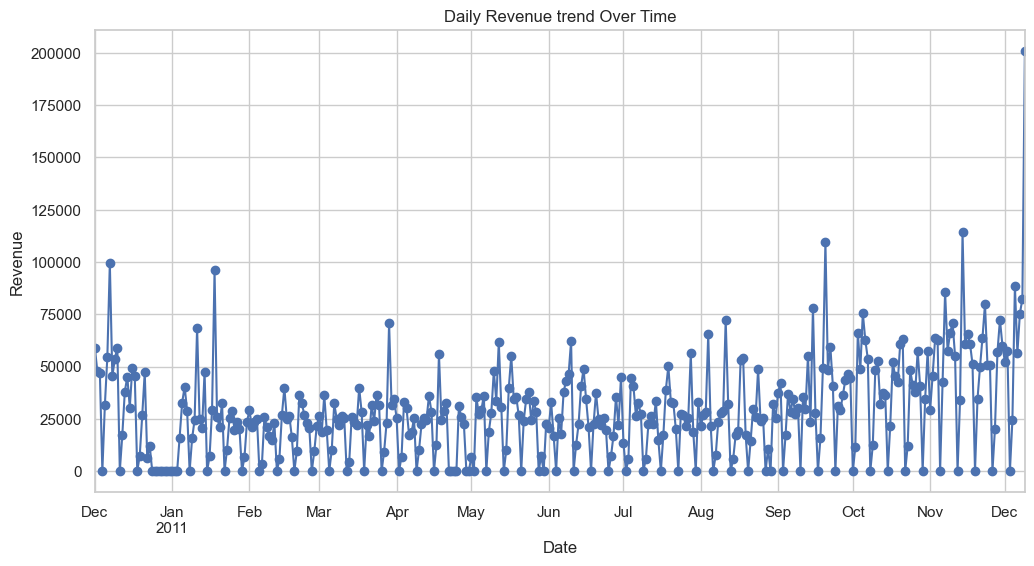

In [45]:
daily = df_clean.resample('D', on='InvoiceDate')['Revenue'].sum() # Group the cleaned dataframe by day (resampled from 'InvoiceDate') and sum the 'Revenue' for each day
daily.plot(figsize=(12, 6), marker='o') # Plot a line graph of daily revenue over time with specified figure size and markers
plt.title('Daily Revenue trend Over Time') # Set the title of the plot
plt.xlabel('Date') # Set the x-axis label
plt.ylabel('Revenue') # Set the y-axis label
plt.show() # Display the plot

## Q7: Which locations generate highest sales?


In [46]:
country_sales = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5) # Group the cleaned dataframe by 'Country', sum the 'Revenue' for each country, and sort in descending order
print("\n🌍 Top 5 Locations:\n", country_sales) # Print the top 5 countries by revenue


🌍 Top 5 Locations:
 Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Name: Revenue, dtype: float64


## Q8: Unusual transactions (Outliers)?

In [47]:
# Using IQR method on quantity to identify outliers
Q1 = df_clean['Quantity'].quantile(0.25) # Calculate the first quartile (Q1) of the 'Quantity' column
Q3 = df_clean['Quantity'].quantile(0.75) # Calculate the third quartile (Q3) of the 'Quantity' column
IQR = Q3 - Q1 # Calculate the interquartile range (IQR) by subtracting Q1 from Q3
lower_bound = Q1 - 1.5 * IQR # Calculate the lower bound for outliers using the IQR method
upper_bound = Q3 + 1.5 * IQR # Calculate the upper bound for outliers using the IQR method
outliers = df_clean[(df_clean['Quantity'] < lower_bound) | (df_clean['Quantity'] > upper_bound)] # Identify outliers in the 'Quantity' column based on the calculated bounds
print(f"Number of outliers in 'Quantity': {outliers.shape[0]}")
outliers.head() # Display the first 5 rows of the outliers dataframe

Number of outliers in 'Quantity': 27355


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Has_CustomerID,Revenue,Year,Month,Day,Weekday,Hour
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,True,54.08,2010,12,1,2,8
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France,True,40.80,2010,12,1,2,8
44,536370,22492,MINI PAINT SET VINTAGE,36,2010-12-01 08:45:00,0.65,12583.0,France,True,23.40,2010,12,1,2,8
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 09:00:00,2.55,13748.0,United Kingdom,True,204.00,2010,12,1,2,9
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,2010-12-01 09:09:00,10.95,15100.0,United Kingdom,True,350.40,2010,12,1,2,9


## ============================================
##  METHOD: STATISTICAL SUMMARY OF THE DATA
## ============================================

In [48]:


# 1. Overall dataset statistics
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Total Transactions (after cleaning): {len(df_clean):,}")
print(f"Total Unique Products: {df_clean['Description'].nunique():,}")
print(f"Total Unique Customers (with ID): {df_clean[df_clean['CustomerID'].notna()]['CustomerID'].nunique():,}")
print(f"Total Unique Countries: {df_clean['Country'].nunique()}")
print(f"Date Range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")

print("\n" + "="*50)
print("REVENUE STATISTICS")
print("="*50)
print(f"Total Revenue: £{df_clean['Revenue'].sum():,.2f}")
print(f"Average Order Value: £{df_clean['Revenue'].mean():,.2f}")
print(f"Median Order Value: £{df_clean['Revenue'].median():,.2f}")
print(f"Min Order Value: £{df_clean['Revenue'].min():,.2f}")
print(f"Max Order Value: £{df_clean['Revenue'].max():,.2f}")
print("="*50)


DATASET OVERVIEW
Total Transactions (after cleaning): 526,052
Total Unique Products: 4,077
Total Unique Customers (with ID): 4,339
Total Unique Countries: 38
Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00

REVENUE STATISTICS
Total Revenue: £10,642,110.80
Average Order Value: £20.23
Median Order Value: £9.92
Min Order Value: £0.00
Max Order Value: £168,469.60


In [49]:

print("\n" + "="*50)
print("QUANTITY STATISTICS")
print("="*50)
print(f"Total Units Sold: {df_clean['Quantity'].sum():,}")
print(f"Average Units per Transaction: {df_clean['Quantity'].mean():.2f}")
print(f"Median Units per Transaction: {df_clean['Quantity'].median():.2f}")

print("\n" + "="*50)
print("CUSTOMER SPENDING STATISTICS")
print("="*50)
customer_spending = df_clean[df_clean['CustomerID'].notna()].groupby('CustomerID')['Revenue'].sum()
print(f"Average Spend per Customer: £{customer_spending.mean():,.2f}")
print(f"Median Spend per Customer: £{customer_spending.median():,.2f}")
print(f"Top Customer Spend: £{customer_spending.max():,.2f}")
print("="*50)


QUANTITY STATISTICS
Total Units Sold: 5,645,017
Average Units per Transaction: 10.73
Median Units per Transaction: 4.00

CUSTOMER SPENDING STATISTICS
Average Spend per Customer: £2,048.22
Median Spend per Customer: £668.56
Top Customer Spend: £280,206.02


## ============================================
## DATA QUALITY REPORT
## ============================================

In [50]:
# ============================================
# METHOD: DATA QUALITY REPORT
# ============================================

print("="*50)
print("DATA QUALITY SUMMARY (After Cleaning)")
print("="*50)

# Before vs After comparison
print(f"Original rows: {len(df):,}")
print(f"Rows after cleaning: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,} ({((len(df) - len(df_clean))/len(df))*100:.1f}%)")

print("\nRemaining Missing Values:")
missing_after = df_clean.isnull().sum()
missing_percent = (missing_after / len(df_clean)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_after,
    'Missing %': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "="*50)
print("CLEANING DECISIONS DOCUMENTED")
print("="*50)
print("✅ Dropped duplicate rows")
print("✅ Removed rows with Quantity <= 0 (returns/cancellations)")
print("✅ Removed rows with UnitPrice <= 0 (invalid entries)")
print("✅ Converted InvoiceDate to datetime format")
print("✅ Stripped whitespace from Description and Country")
print("✅ Flagged missing Customer IDs (kept for revenue, excluded from customer ranking)")
print("✅ Created Revenue = Quantity × UnitPrice")
print("✅ Extracted Year, Month, Day, Weekday, Hour from InvoiceDate")

DATA QUALITY SUMMARY (After Cleaning)
Original rows: 536,641
Rows after cleaning: 526,052
Rows removed: 10,589 (2.0%)

Remaining Missing Values:
             Missing Count  Missing %
Description            592   0.112536
CustomerID          133320  25.343502

CLEANING DECISIONS DOCUMENTED
✅ Dropped duplicate rows
✅ Removed rows with Quantity <= 0 (returns/cancellations)
✅ Removed rows with UnitPrice <= 0 (invalid entries)
✅ Converted InvoiceDate to datetime format
✅ Stripped whitespace from Description and Country
✅ Flagged missing Customer IDs (kept for revenue, excluded from customer ranking)
✅ Created Revenue = Quantity × UnitPrice
✅ Extracted Year, Month, Day, Weekday, Hour from InvoiceDate


In [51]:
# ============================================
# EXPORT CLEANED DATA FOR POWER BI
# ============================================

# 1. Create a copy of your cleaned dataframe (just in case)
df_powerbi = df_clean.copy()

# 2. Optional: Create aggregated tables for faster Power BI performance
# (This reduces the row count and speeds up your dashboard)

# Monthly aggregated sales
monthly_agg = df_powerbi.groupby(
    pd.Grouper(key='InvoiceDate', freq='M')
).agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'InvoiceNo': 'nunique'  # Number of orders per month
}).reset_index()
monthly_agg.columns = ['Month', 'Total_Revenue', 'Total_Quantity', 'Order_Count']

# Product-level aggregation
product_agg = df_powerbi.groupby(['Description', 'StockCode']).agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'InvoiceNo': 'nunique'  # Number of orders containing this product
}).reset_index()

# Customer-level aggregation (excluding missing CustomerID)
customer_agg = df_powerbi[df_powerbi['CustomerID'].notna()].groupby('CustomerID').agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'InvoiceNo': 'nunique'  # Number of orders per customer
}).reset_index()

# Country-level aggregation
country_agg = df_powerbi.groupby('Country').agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'InvoiceNo': 'nunique'
}).reset_index()

# 3. Export all to CSV (Power BI loves CSV)
df_powerbi.to_csv('ecommerce_clean_data.csv', index=False)
monthly_agg.to_csv('monthly_aggregated.csv', index=False)
product_agg.to_csv('product_aggregated.csv', index=False)
customer_agg.to_csv('customer_aggregated.csv', index=False)
country_agg.to_csv('country_aggregated.csv', index=False)

print("✅ All files exported successfully!")
print(f"Main data: {len(df_powerbi):,} rows")
print(f"Monthly agg: {len(monthly_agg)} rows")
print(f"Product agg: {len(product_agg):,} rows")
print(f"Customer agg: {len(customer_agg):,} rows")

✅ All files exported successfully!
Main data: 526,052 rows
Monthly agg: 13 rows
Product agg: 4,319 rows
Customer agg: 4,339 rows
